# Deep Learning PR 3 — Computer Vision Pipeline

## Objective
This project demonstrates classical image processing, face detection using YuNet, and object detection using YOLOv8.

## Tasks
1. Environment Setup & Morphological Operations
2. Bitwise Operations & Image Histograms
3. Face Detection with YuNet
4. Object Detection with YOLOv8
5. Integrated Pipeline & Final Comparison

In [1]:
!pip install opencv-python==5.0.0.* opencv-contrib-python==5.0.0.* ultralytics matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
   ---------------------------------------- 0.0/53.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/53.8 MB 3.3 MB/s eta 0:00:17
   - -------------------------------------- 1.6/53.8 MB 3.8 MB/s eta 0:00:14
   - -------------------------------------- 2.4/53.8 MB 3.8 MB/s eta 0:00:14
   -- ------------------------------------- 3.1/53.8 MB 3.9 MB/s eta 0:00:13
   -- -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.11.2 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.3 which is incompatible.
ydata-profiling 4.18.1 requires panda

# Task 1 — Environment Setup, Image I/O & Morphological Operations

### Objective
Set up the computer vision environment, load images, and understand morphological operations.

### Expected Output
Loaded images, binary image, four morphological transformations, and kernel comparison plots.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)

OpenCV Version: 5.0.0
NumPy Version: 2.4.3


In [3]:
image_path = "data/images/solid dice.jpg"

img_color = cv2.imread(image_path)

if img_color is None:
    print("Image not found!")
else:
    print("Image loaded successfully")
    print("Shape:", img_color.shape)
    print("Data type:", img_color.dtype)

Image loaded successfully
Shape: (5376, 3584, 3)
Data type: uint8


In [4]:
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

print("Gray Shape:", img_gray.shape)
print("Gray Data Type:", img_gray.dtype)

Gray Shape: (5376, 3584)
Gray Data Type: uint8


## Display helper function

In [5]:
def show(img, title="Image", cmap=None):
    plt.figure(figsize=(6, 5))
    
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap=cmap if cmap else "gray")
    
    plt.title(title)
    plt.axis("off")
    plt.show()

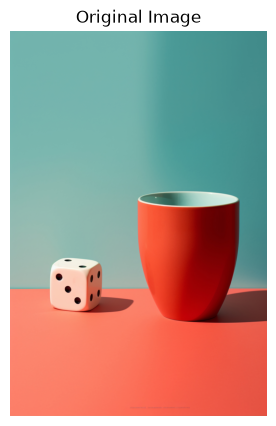

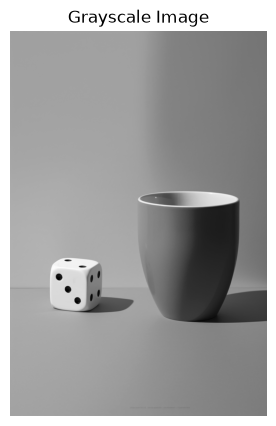

In [6]:
show(img_color, "Original Image")
show(img_gray, "Grayscale Image")

## 1.2 Binarization

A grayscale image is converted into a binary image using thresholding.

Pixels above 127 become 255 (white), while pixels below 127 become 0 (black).

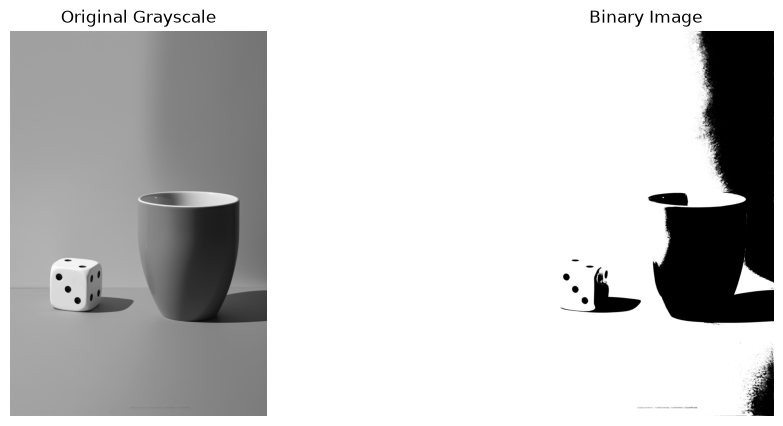

In [7]:
_, binary = cv2.threshold(
    img_gray,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.show()

## Four Morphological Operations

In [8]:
kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(binary, kernel, iterations=1)

dilated = cv2.dilate(binary, kernel, iterations=1)

opened = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

closed = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

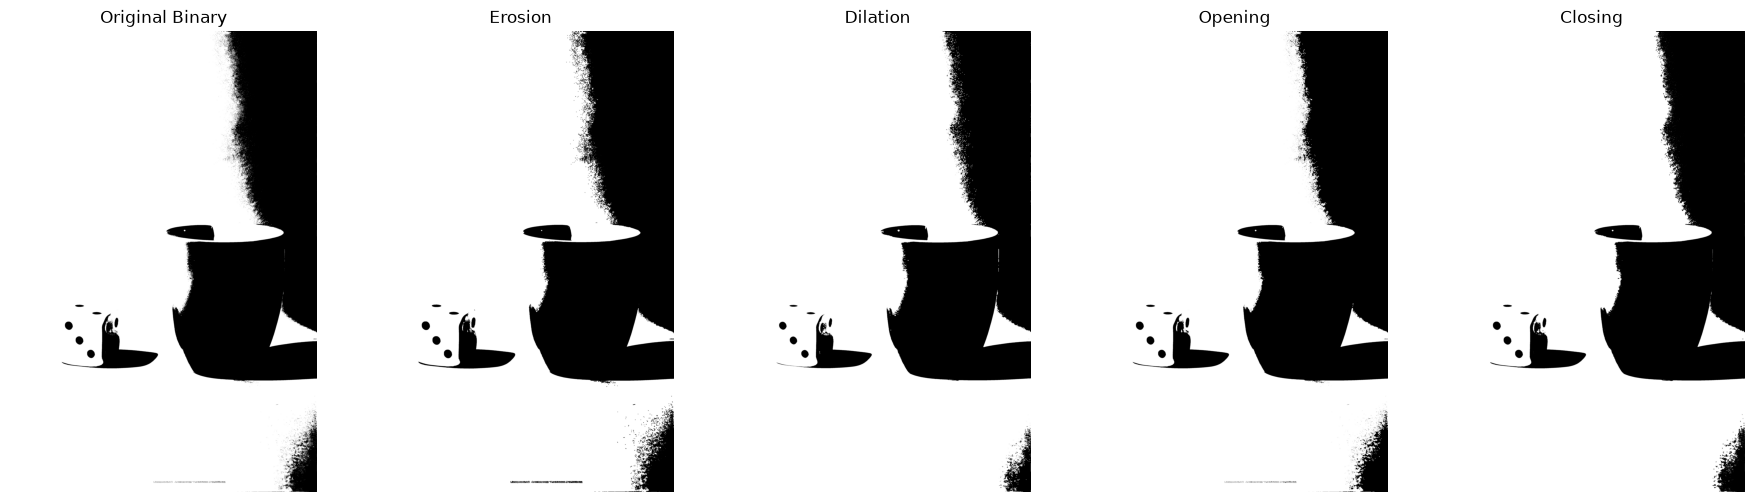

In [9]:
plt.figure(figsize=(18, 5))

images = [
    binary,
    eroded,
    dilated,
    opened,
    closed
]

titles = [
    "Original Binary",
    "Erosion",
    "Dilation",
    "Opening",
    "Closing"
]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Kernel Shape × Size

In [10]:
kernel_shapes = {
    "RECT": cv2.MORPH_RECT,
    "ELLIPSE": cv2.MORPH_ELLIPSE,
    "CROSS": cv2.MORPH_CROSS
}

sizes = [3, 5, 9]

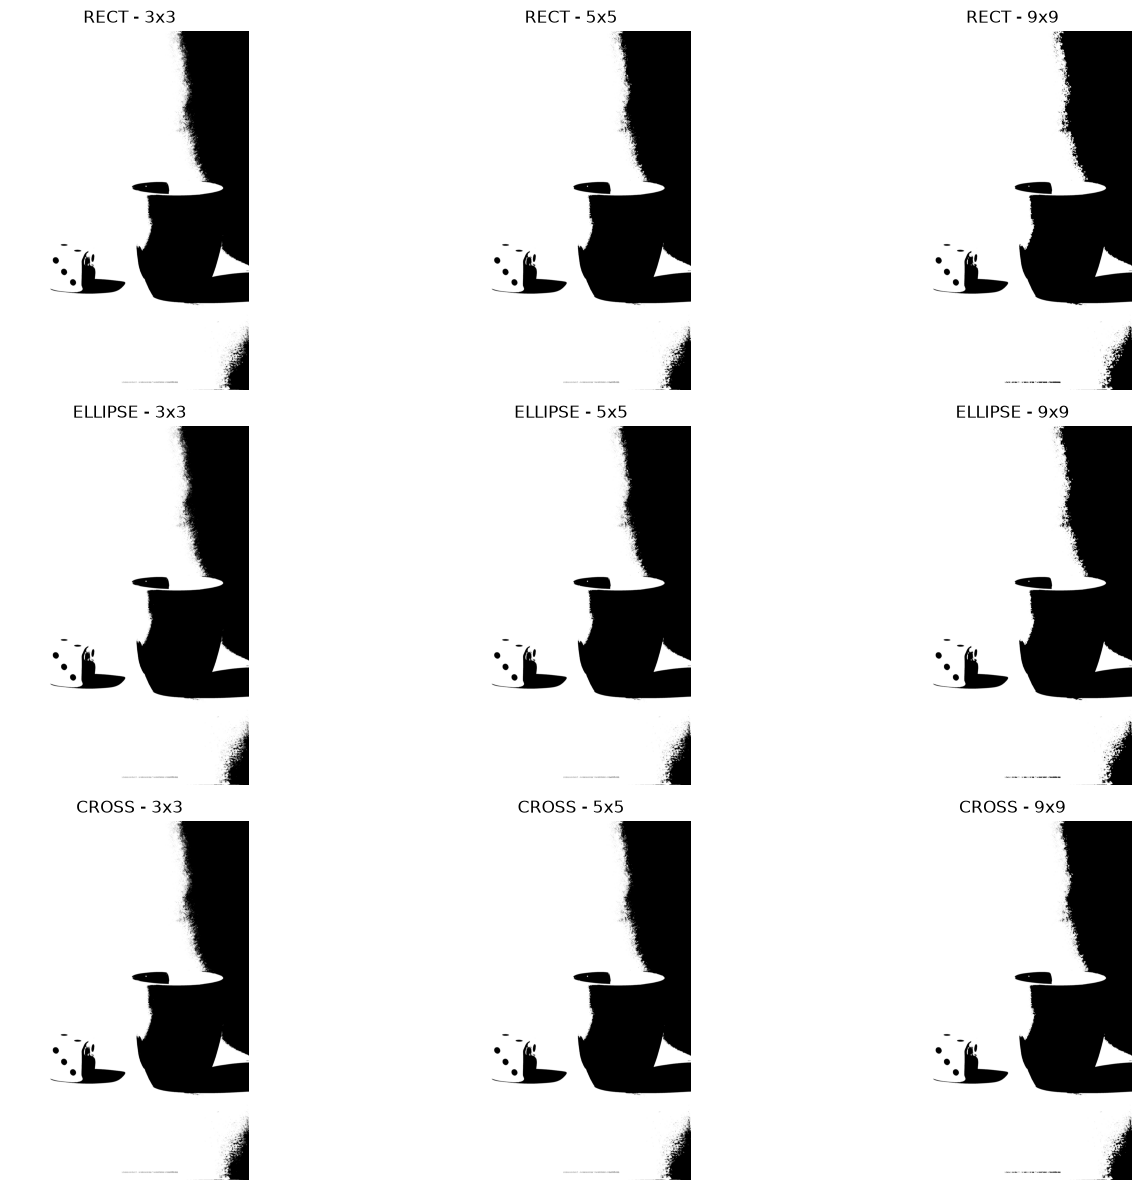

In [11]:
plt.figure(figsize=(15, 12))

plot_index = 1

for shape_name, shape_type in kernel_shapes.items():
    
    for size in sizes:
        
        kernel = cv2.getStructuringElement(
            shape_type,
            (size, size)
        )
        
        opened_img = cv2.morphologyEx(
            binary,
            cv2.MORPH_OPEN,
            kernel
        )
        
        plt.subplot(3, 3, plot_index)
        plt.imshow(opened_img, cmap="gray")
        plt.title(f"{shape_name} - {size}x{size}")
        plt.axis("off")
        
        plot_index += 1

plt.tight_layout()
plt.show()

## Why Morphological Operations Work

### Erosion
Erosion behaves like a local minimum filter. It shrinks white regions and removes small bright noise.

### Dilation
Dilation behaves like a local maximum filter. It expands white regions and fills small dark gaps.

### Opening
Opening = Erosion → Dilation.

It is useful for removing small noise while preserving the overall shape of the object.

### Closing
Closing = Dilation → Erosion.

It is useful for filling small holes and gaps inside objects.

### Real-world Applications

- Erosion: removing small unwanted bright regions from a binary mask.
- Dilation: connecting broken object regions.
- Opening: removing salt-and-pepper noise before object detection.
- Closing: filling small holes in an object mask before passing it to a detector.

In [12]:
mask1 = np.zeros((400, 400), dtype=np.uint8)
mask2 = np.zeros((400, 400), dtype=np.uint8)

cv2.circle(
    mask1,
    (200, 200),
    100,
    255,
    -1
)

cv2.rectangle(
    mask2,
    (100, 100),
    (300, 300),
    255,
    -1
)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(400, 400), dtype=uint8)

In [14]:
bitwise_and = cv2.bitwise_and(mask1, mask2)
bitwise_or = cv2.bitwise_or(mask1, mask2)
bitwise_xor = cv2.bitwise_xor(mask1, mask2)
bitwise_not = cv2.bitwise_not(mask1)

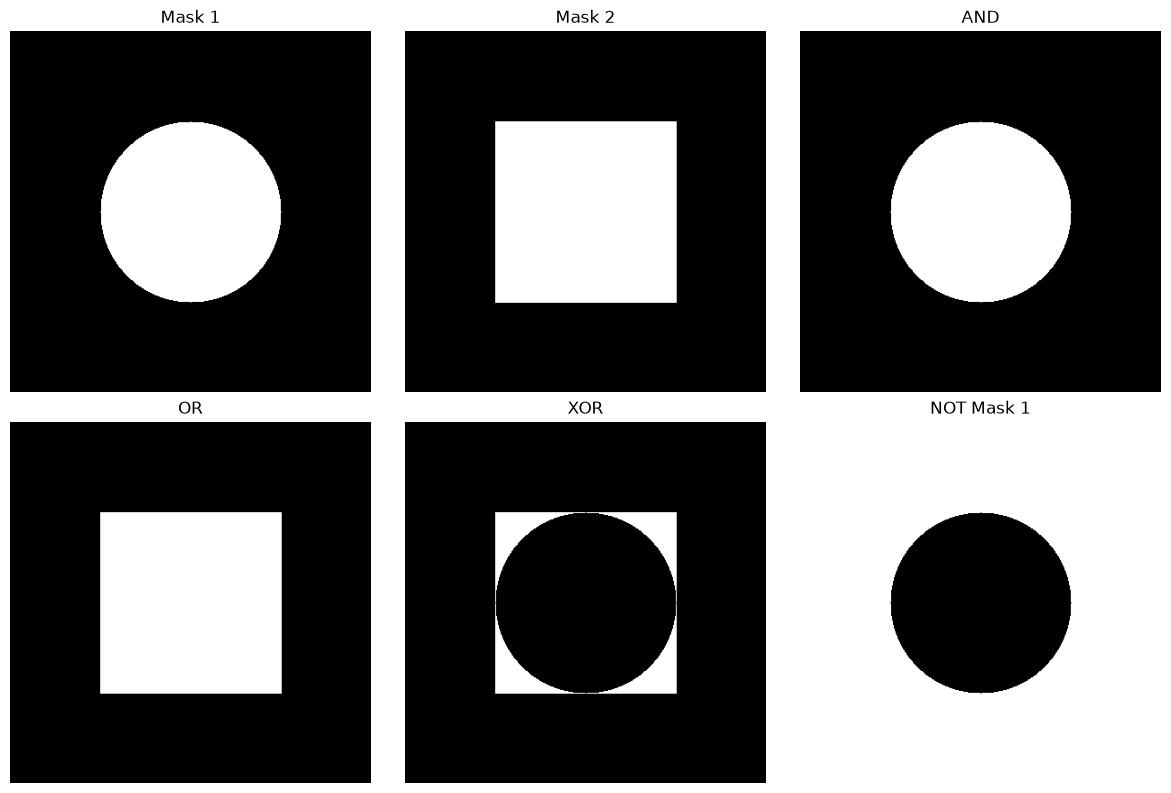

In [15]:
images = [
    mask1,
    mask2,
    bitwise_and,
    bitwise_or,
    bitwise_xor,
    bitwise_not
]

titles = [
    "Mask 1",
    "Mask 2",
    "AND",
    "OR",
    "XOR",
    "NOT Mask 1"
]

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Masked overlay

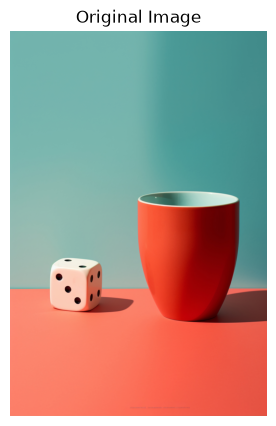

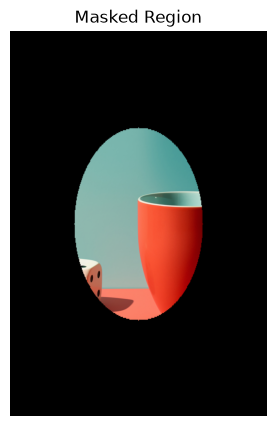

In [17]:
mask1_full = cv2.resize(
    mask1,
    (img_color.shape[1], img_color.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

masked_image = cv2.bitwise_and(
    img_color,
    img_color,
    mask=mask1_full
)

show(img_color, "Original Image")
show(masked_image, "Masked Region")

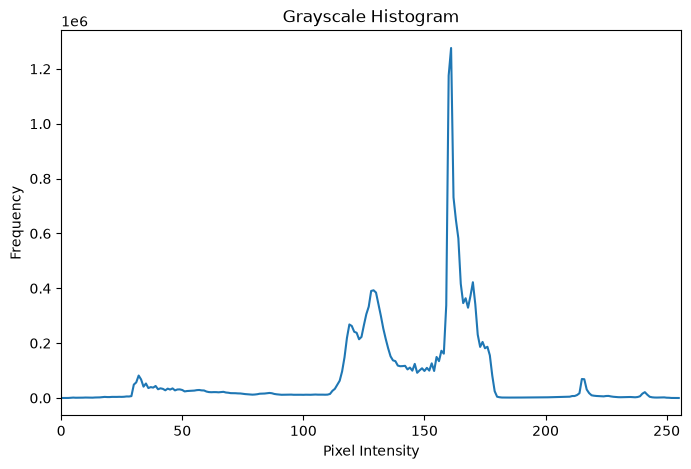

In [18]:
gray_hist = cv2.calcHist(
    [img_gray],
    [0],
    None,
    [256],
    [0, 256]
)

plt.figure(figsize=(8, 5))
plt.plot(gray_hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.show()

#  BGR Histograms

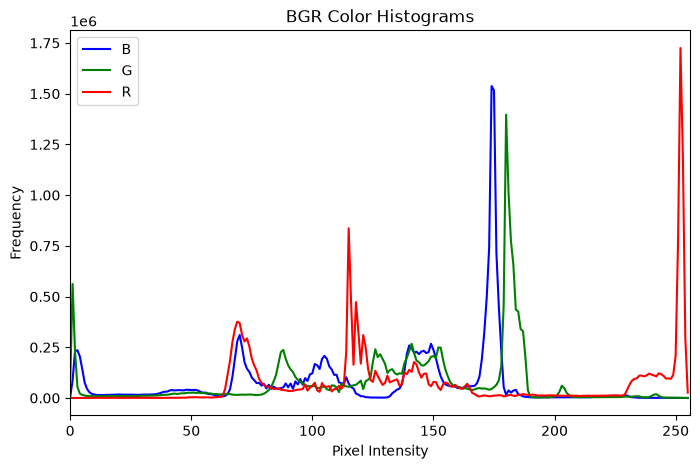

In [19]:
colors = ["b", "g", "r"]

plt.figure(figsize=(8, 5))

for i, color in enumerate(colors):
    
    hist = cv2.calcHist(
        [img_color],
        [i],
        None,
        [256],
        [0, 256]
    )
    
    plt.plot(hist, color=color, label=color.upper())

plt.title("BGR Color Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.xlim([0, 256])
plt.show()

#  Brightness & Contrast

In [20]:
bright_high_contrast = cv2.convertScaleAbs(
    img_color,
    alpha=1.5,
    beta=30
)

dark_low_contrast = cv2.convertScaleAbs(
    img_color,
    alpha=0.7,
    beta=-30
)

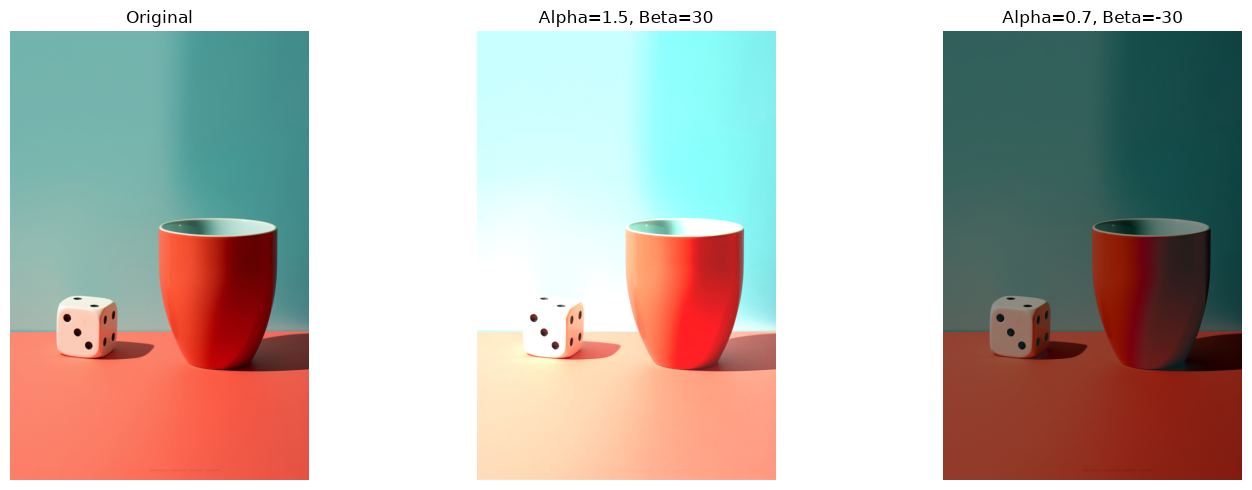

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(bright_high_contrast, cv2.COLOR_BGR2RGB))
plt.title("Alpha=1.5, Beta=30")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(dark_low_contrast, cv2.COLOR_BGR2RGB))
plt.title("Alpha=0.7, Beta=-30")
plt.axis("off")

plt.tight_layout()
plt.show()

## Why Alpha and Beta Matter

The brightness and contrast transformation is:

new_pixel = alpha × pixel + beta

- alpha controls contrast.
- beta controls brightness.

A higher alpha increases contrast.
A lower alpha decreases contrast.

A positive beta makes the image brighter.
A negative beta makes the image darker.

A narrow histogram generally indicates low contrast.

A histogram heavily clipped near 0 or 255 may indicate underexposure or overexposure.

Histograms therefore help us decide whether an image requires preprocessing before face or object detection.

# Task 3 — Face Detection with YuNet

### Objective
Detect human faces using OpenCV YuNet and analyze confidence thresholds.

### Expected Output
Face bounding boxes, 5 facial landmarks, confidence scores, webcam detection, threshold comparison, and privacy blur.

In [22]:
import urllib.request

url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"

urllib.request.urlretrieve(
    url,
    "face_detection_yunet_2023mar.onnx"
)

print("Model downloaded successfully!")

Model downloaded successfully!


In [26]:
yunet_model = "data/models/face_detection_yunet_2023mar.onnx"

img_h, img_w = img_color.shape[:2]

detector = cv2.FaceDetectorYN_create(
    yunet_model,
    "",
    (img_w, img_h),
    score_threshold=0.9
)

detector.setInputSize((img_w, img_h))

## 3.2 Detect Faces on Multiple Static Images

We will test YuNet on multiple images with different face conditions.

The test images should include different lighting, poses, number of people, and ideally one side-profile or partially occluded face.

In [27]:
face_image_paths = [
    "data/images/my_photo.jpg",
    "data/images/persons.jpeg"
]

face_image_paths

['data/images/my_photo.jpg', 'data/images/persons.jpeg']


Image: data/images/my_photo.jpg
Shape: (720, 1280, 3)
Data type: uint8


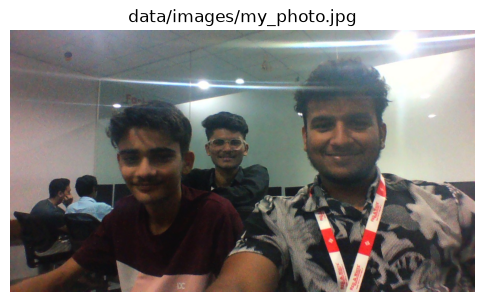


Image: data/images/persons.jpeg
Shape: (324, 617, 3)
Data type: uint8


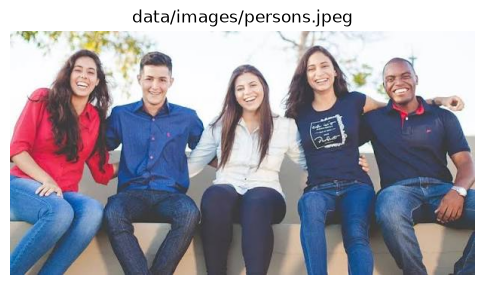

In [28]:
for path in face_image_paths:
    
    image = cv2.imread(path)
    
    if image is None:
        print(f"Could not load: {path}")
        continue
    
    print(f"\nImage: {path}")
    print("Shape:", image.shape)
    print("Data type:", image.dtype)
    
    show(image, path)

In [29]:
def detect_faces_yunet(image_path, threshold=0.9):
    
    image = cv2.imread(image_path)
    
    if image is None:
        print(f"Could not load: {image_path}")
        return None, None
    
    h, w = image.shape[:2]
    
    detector = cv2.FaceDetectorYN_create(
        yunet_model,
        "",
        (w, h),
        score_threshold=threshold
    )
    
    detector.setInputSize((w, h))
    
    _, faces = detector.detect(image)
    
    return image, faces

In [30]:
for path in face_image_paths:
    
    image, faces = detect_faces_yunet(path)
    
    count = 0 if faces is None else len(faces)
    
    print(f"{path} → Detected faces: {count}")

data/images/my_photo.jpg → Detected faces: 3
data/images/persons.jpeg → Detected faces: 5


In [31]:
def draw_yunet_results(image, faces):
    
    output = image.copy()
    
    if faces is None:
        return output
    
    for face in faces:
        
        # Bounding box
        x, y, w, h = face[:4].astype(int)
        
        # Confidence
        confidence = face[-1]
        
        # Green face box
        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )
        
        # Five landmarks
        landmarks = face[4:14].reshape(5, 2).astype(int)
        
        for point in landmarks:
            
            cv2.circle(
                output,
                tuple(point),
                4,
                (255, 0, 0),
                -1
            )
        
        # Confidence
        cv2.putText(
            output,
            f"Face: {confidence:.2f}",
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )
    
    return output

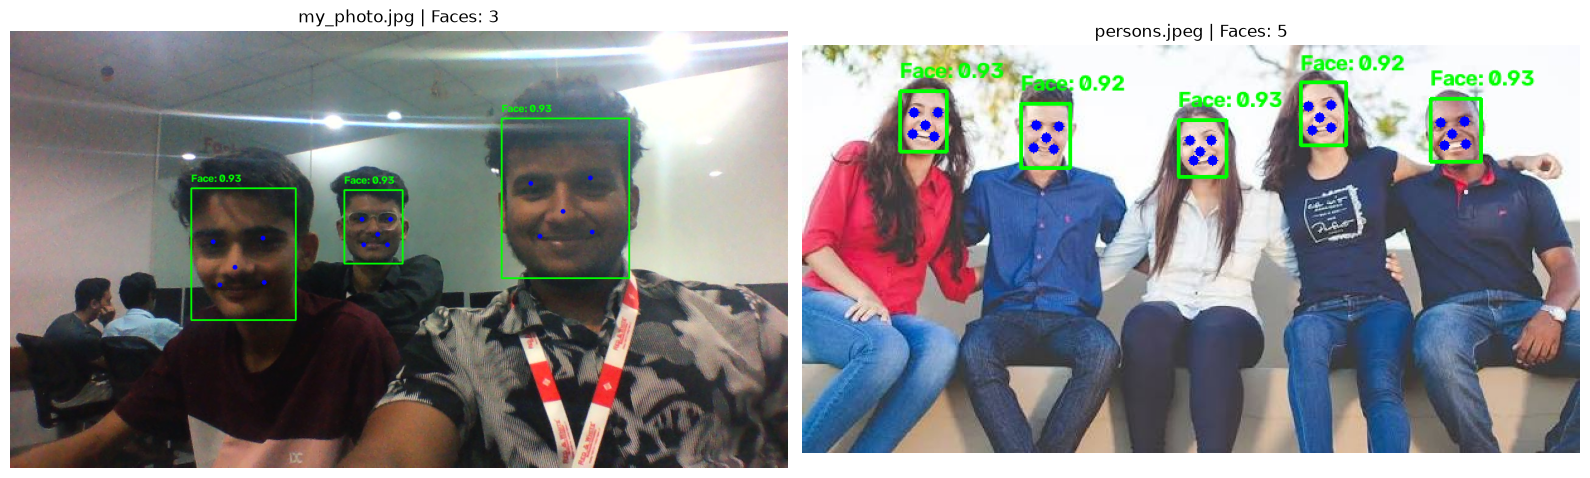

In [32]:
plt.figure(figsize=(16, 10))

for i, path in enumerate(face_image_paths):
    
    image, faces = detect_faces_yunet(path)
    
    output = draw_yunet_results(image, faces)
    
    plt.subplot(2, 2, i + 1)
    
    plt.imshow(
        cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    )
    
    count = 0 if faces is None else len(faces)
    
    plt.title(
        f"{os.path.basename(path)} | Faces: {count}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

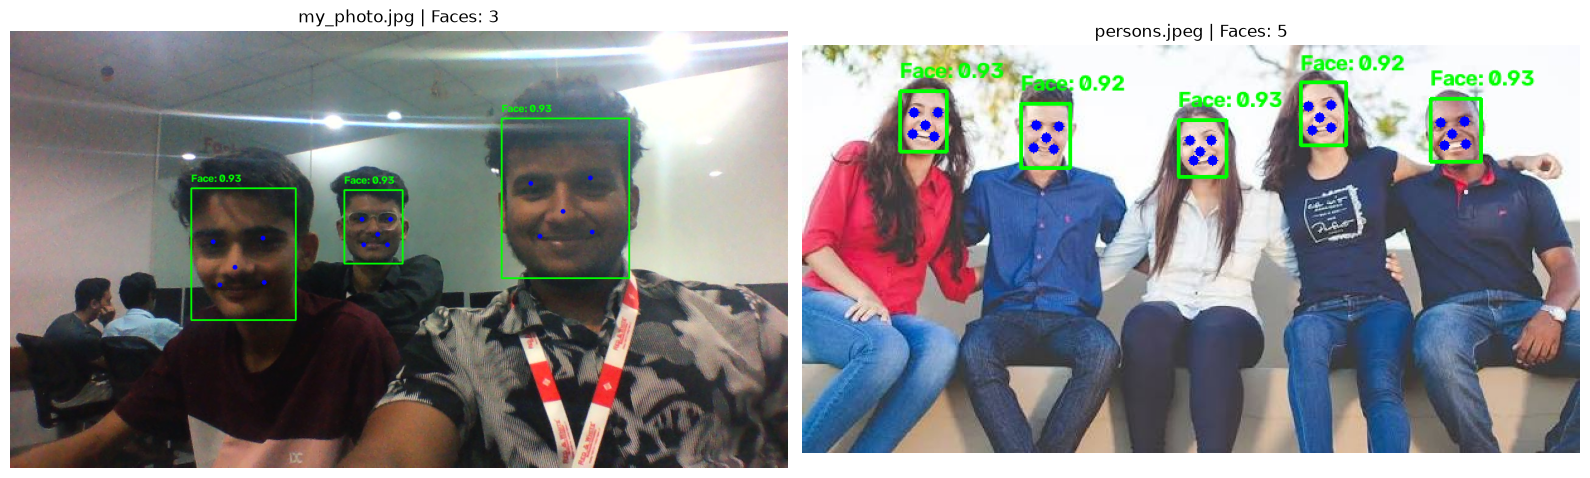

In [33]:
plt.figure(figsize=(16, 10))

for i, path in enumerate(face_image_paths):
    
    image, faces = detect_faces_yunet(path)
    
    output = draw_yunet_results(image, faces)
    
    plt.subplot(2, 2, i + 1)
    
    plt.imshow(
        cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    )
    
    count = 0 if faces is None else len(faces)
    
    plt.title(
        f"{os.path.basename(path)} | Faces: {count}"
    )
    
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "plots/face_detection_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
_, faces = detector.detect(img_color)

print("Detected faces:", 0 if faces is None else len(faces))

Detected faces: 0


In [35]:
face_image_paths = [
    "data/images/my_photo.jpg",
    "data/images/persons.jpeg"
]

data/images/my_photo.jpg
Shape: (720, 1280, 3)


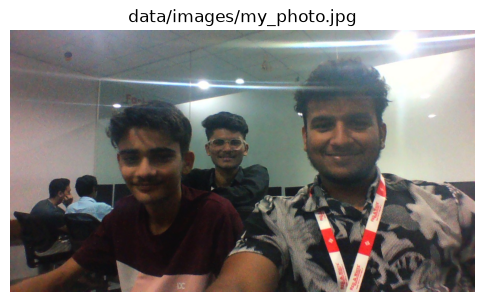

data/images/persons.jpeg
Shape: (324, 617, 3)


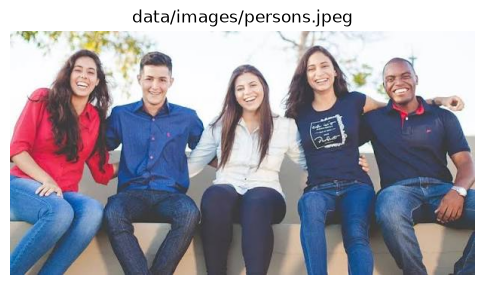

In [36]:
for path in face_image_paths:
    
    image = cv2.imread(path)
    
    print(path)
    print("Shape:", image.shape)
    
    show(image, path)

In [37]:
face_image_paths = [
    "data/images/my_photo.jpg",
    "data/images/persons.jpeg",
    "data/images/face_profile.jpg",
    "data/images/face_sunglasses.jpg"
]

## 3.3 Real-Time Face Detection Using Webcam

The YuNet face detector is applied to live webcam frames.

For every frame:
1. Capture the frame using OpenCV.
2. Set the detector input size according to the frame dimensions.
3. Detect faces.
4. Draw bounding boxes, five facial landmarks, and confidence scores.
5. Calculate and report the achieved FPS.

In [41]:
import cv2
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    print("Webcam started. Press Q to stop.")

frame_count = 0
start_time = time.time()

input_size = None

while True:
    
    ret, frame = cap.read()
    
    if not ret:
        print("Could not read frame.")
        break
    
    h, w = frame.shape[:2]
    
    # Set input size only when frame size changes
    if input_size != (w, h):
        detector.setInputSize((w, h))
        input_size = (w, h)
    
    # YuNet detection
    _, faces = detector.detect(frame)
    
    if faces is not None:
        
        for face in faces:
            
            x, y, fw, fh = face[:4].astype(int)
            confidence = face[-1]
            
            # Face bounding box
            cv2.rectangle(
                frame,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )
            
            # Five landmarks
            landmarks = face[4:14].reshape(5, 2).astype(int)
            
            for point in landmarks:
                cv2.circle(
                    frame,
                    tuple(point),
                    3,
                    (255, 0, 0),
                    -1
                )
            
            # Confidence
            cv2.putText(
                frame,
                f"Yo , this is Rajesh {confidence:.2f}",
                (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )
    
    frame_count += 1
    
    # Current FPS
    elapsed = time.time() - start_time
    
    if elapsed > 0:
        fps = frame_count / elapsed
    else:
        fps = 0
    
    cv2.putText(
        frame,
        f"FPS: {fps:.2f}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )
    
    cv2.imshow(
        "YuNet Face Detection",
        frame
    )
    
    # Press Q to quit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print(f"Frames processed: {frame_count}")
print(f"Average FPS: {fps:.2f}")

Webcam started. Press Q to stop.
Frames processed: 3105
Average FPS: 19.86


## 3.4 Score Threshold Experiment

The YuNet detector is tested with three confidence thresholds:

- 0.5
- 0.7
- 0.9

A lower threshold can detect more candidate faces but may also allow more false positives.

A higher threshold produces stricter detections but may miss difficult faces.

   Threshold  Detected Faces
0        0.5               4
1        0.7               4
2        0.9               3


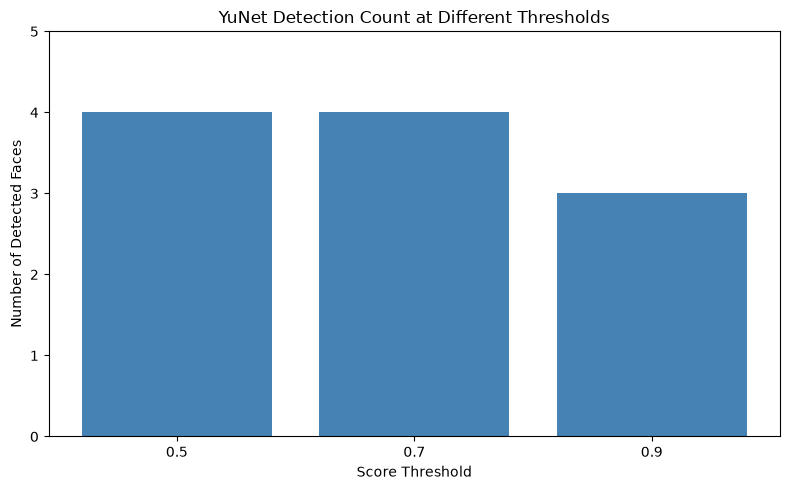

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

# Use a face image, not the dice image
image_path = "data/images/my_photo.jpg"   # or "data/images/persons.jpeg"

img_color = cv2.imread(image_path)

if img_color is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

img_h, img_w = img_color.shape[:2]

yunet_model = "data/models/face_detection_yunet_2023mar.onnx"

thresholds = [0.5, 0.7, 0.9]
threshold_results = []

for threshold in thresholds:
    detector = cv2.FaceDetectorYN_create(
        yunet_model,
        "",
        (img_w, img_h),
        score_threshold=threshold
    )
    detector.setInputSize((img_w, img_h))
    _, faces = detector.detect(img_color)

    face_count = 0 if faces is None else len(faces)
    threshold_results.append({
        "Threshold": threshold,
        "Detected Faces": face_count
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)

plt.figure(figsize=(8, 5))
plt.bar(
    threshold_df["Threshold"].astype(str),
    threshold_df["Detected Faces"],
    color="steelblue"
)

plt.title("YuNet Detection Count at Different Thresholds")
plt.xlabel("Score Threshold")
plt.ylabel("Number of Detected Faces")
plt.ylim(0, max(1, threshold_df["Detected Faces"].max() + 1))
plt.tight_layout()
plt.show()

In [46]:
print("Image exists:", os.path.exists(image_path))
print("Model exists:", os.path.exists(yunet_model))
print("Image shape:", img_color.shape)

Image exists: True
Model exists: True
Image shape: (720, 1280, 3)


## 3.5 Why YuNet?

YuNet is a compact CNN-based face detector available through OpenCV's FaceDetectorYN API.

It can return:

- Face bounding boxes
- Five facial landmarks
- Confidence scores

The score threshold controls the trade-off between missed detections and false positives.

### Threshold Selection

A lower threshold such as 0.5 can improve recall because more candidate faces are accepted, but false positives may increase.

A higher threshold such as 0.9 is more strict and can reduce false positives, but difficult or low-quality faces may be missed.

For a real-time security camera, a moderate threshold such as 0.7 can be a practical starting point.

For offline photo tagging, the threshold can be increased when precision is more important.

YuNet is suitable for real-time applications because it is lightweight compared with larger face-detection models.

# Task 4 — Object Detection with YOLOv8

## Objective

Detect multiple real-world objects using a pretrained YOLOv8 model.

## Expected Output

Object bounding boxes, class labels, confidence scores, webcam detection, threshold experiments, and per-class detection summary.

In [48]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully.")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\DELL\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
WARNING Download failure, retrying 1/3 in 5s https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8n.pt... HTTPSConnectionPool(host='github.com', port=443): Max retries exceeded with url: /ultralytics/assets/releases/download/v8.4.0/yolov8n.pt (Caused by NameResolutionError("HTTPSConnection(host='github.com', port=443): Failed to resolve 'github.com' ([Errno 11001] getaddrinfo failed)"))
WARNING Download failure, retrying 2/3 in 10s https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8n.pt... HTTPSConnectionPool(host='github.com', port=443): Max retries exceeded with url: /ultralytics/assets/releases/download/v8.4.0/yolov8n.pt (Caused by NameResolutionE

In [49]:
yolo_image_paths = [
    "data/images/cars.jpeg",
    "data/images/bottles.jpg",
    "data/images/Chairs.jpeg"
]

data/images/cars.jpeg
Shape: (737, 415, 3)


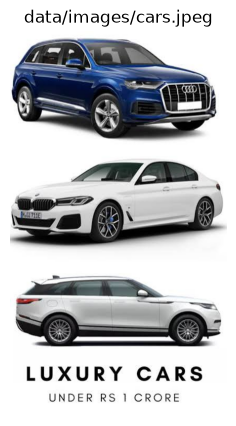

data/images/bottles.jpg
Shape: (675, 1200, 3)


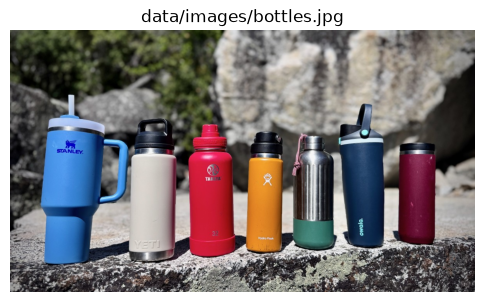

data/images/Chairs.jpeg
Shape: (447, 447, 3)


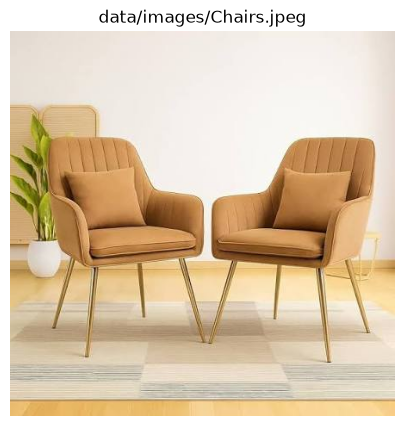

In [50]:
for path in yolo_image_paths:
    
    print(path)
    
    image = cv2.imread(path)
    
    if image is None:
        print("Image not found!")
    else:
        print("Shape:", image.shape)
        show(image, path)

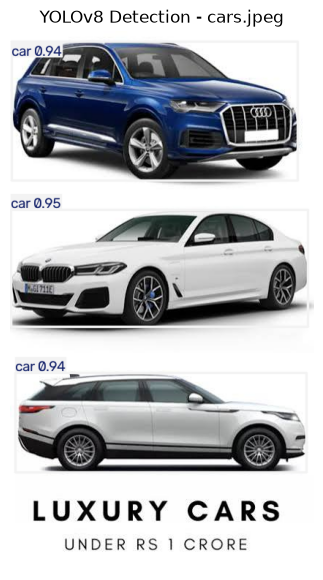

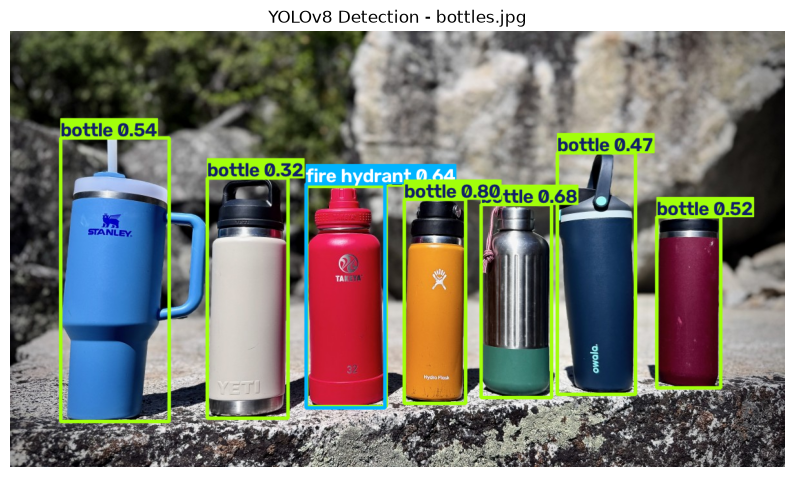

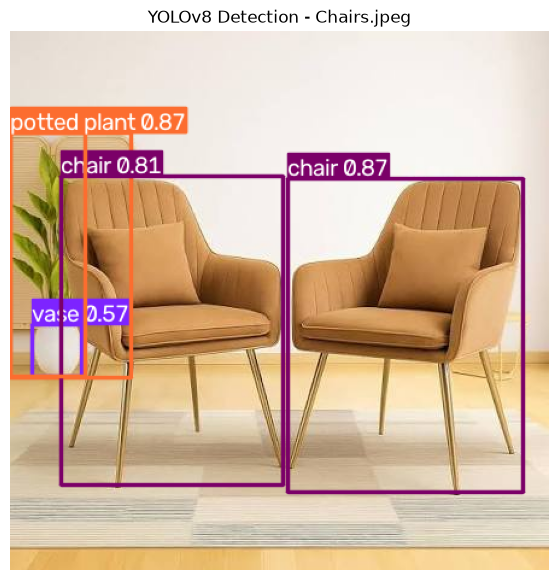

In [51]:
yolo_results = {}

for path in yolo_image_paths:
    
    results = model(
        path,
        verbose=False
    )
    
    yolo_results[path] = results[0]
    
    annotated = results[0].plot()
    
    plt.figure(figsize=(10, 7))
    
    plt.imshow(
        cv2.cvtColor(
            annotated,
            cv2.COLOR_BGR2RGB
        )
    )
    
    plt.title(
        f"YOLOv8 Detection - {os.path.basename(path)}"
    )
    
    plt.axis("off")
    plt.show()

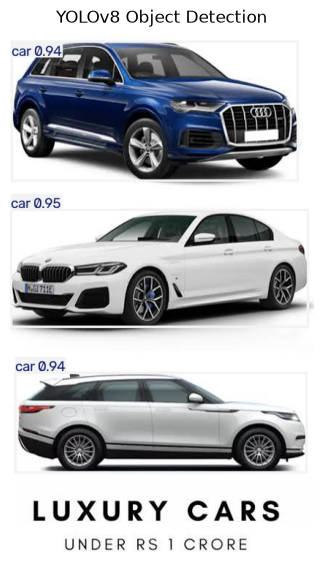

In [52]:
os.makedirs("plots", exist_ok=True)

path = yolo_image_paths[0]

annotated = yolo_results[path].plot()

plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
)

plt.title("YOLOv8 Object Detection")

plt.axis("off")

plt.savefig(
    "plots/yolo_detections.png",
    dpi=300,
    bbox_inches="tight"
)

## 4.2 Real-Time YOLO Object Detection

The YOLOv8 model is applied to live webcam frames.

The annotated output displays bounding boxes, object class names, confidence scores, and the achieved FPS.

In [53]:
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam.")
else:
    print("YOLO webcam started. Press Q to stop.")

frame_count = 0
start_time = time.time()

while True:
    
    ret, frame = cap.read()
    
    if not ret:
        break
    
    results = model(
        frame,
        verbose=False
    )
    
    annotated = results[0].plot()
    
    frame_count += 1
    
    elapsed = time.time() - start_time
    
    fps = frame_count / elapsed if elapsed > 0 else 0
    
    cv2.putText(
        annotated,
        f"FPS: {fps:.2f}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )
    
    cv2.imshow(
        "YOLOv8 Webcam",
        annotated
    )
    
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print(f"YOLO Average FPS: {fps:.2f}")

YOLO webcam started. Press Q to stop.
YOLO Average FPS: 6.94


In [54]:
conf_values = [0.25, 0.5, 0.75]

conf_results = []

test_image = "data/images/cars.jpeg"

for conf in conf_values:
    
    results = model(
        test_image,
        conf=conf,
        verbose=False
    )
    
    count = len(results[0].boxes)
    
    conf_results.append({
        "Confidence": conf,
        "Detections": count
    })

conf_df = pd.DataFrame(conf_results)

conf_df

,Confidence,Detections
0,0.25,3
1,0.50,3
2,0.75,3


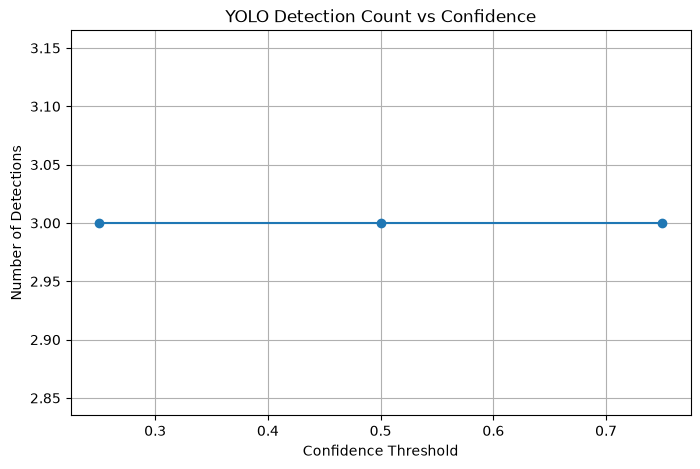

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(
    conf_df["Confidence"],
    conf_df["Detections"],
    marker="o"
)

plt.title("YOLO Detection Count vs Confidence")
plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Detections")

plt.grid(True)
plt.show()

### Confidence Threshold Observation

When the confidence threshold increases, YOLO becomes more selective.

A lower threshold may retain more detections, including uncertain predictions.

A higher threshold removes low-confidence detections but may also remove valid objects.

In [58]:
iou_values = [0.3, 0.5, 0.7]

iou_results = []

for iou in iou_values:
    
    results = model(
        test_image,
        conf=0.25,
        iou=iou,
        verbose=False
    )
    
    count = len(results[0].boxes)
    
    iou_results.append({
        "IoU": iou,
        "Detections": count
    })

iou_df = pd.DataFrame(iou_results)

iou_df

,IoU,Detections
0,0.3,3
1,0.5,3
2,0.7,3


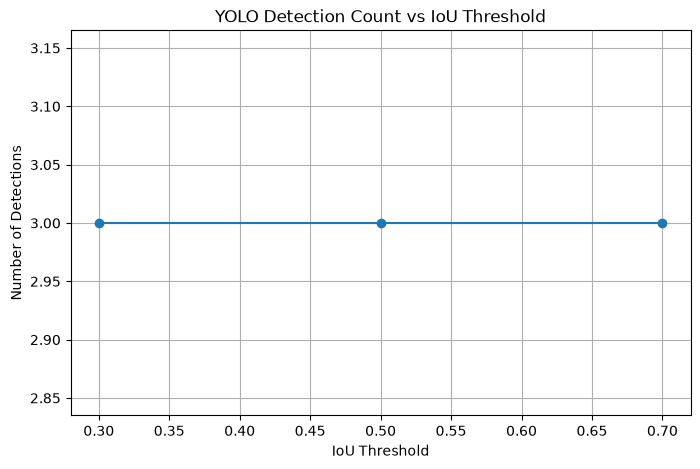

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    iou_df["IoU"],
    iou_df["Detections"],
    marker="o"
)

plt.title("YOLO Detection Count vs IoU Threshold")
plt.xlabel("IoU Threshold")
plt.ylabel("Number of Detections")

plt.grid(True)
plt.show()

In [60]:
class_counts = {}

for path in yolo_image_paths:
    
    results = model(
        path,
        verbose=False
    )
    
    result = results[0]
    
    if result.boxes is None:
        continue
    
    for cls_id in result.boxes.cls:
        
        class_id = int(cls_id)
        
        class_name = model.names[class_id]
        
        class_counts[class_name] = (
            class_counts.get(class_name, 0) + 1
        )

class_counts

{'car': 3,
 'bottle': 7,
 'fire hydrant': 1,
 'potted plant': 2,
 'chair': 2,
 'vase': 1}

In [61]:
class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Count"]
)

class_df = class_df.sort_values(
    "Count",
    ascending=False
)

class_df

,Class,Count
1,bottle,7
0,car,3
3,potted plant,2
4,chair,2
2,fire hydrant,1
5,vase,1


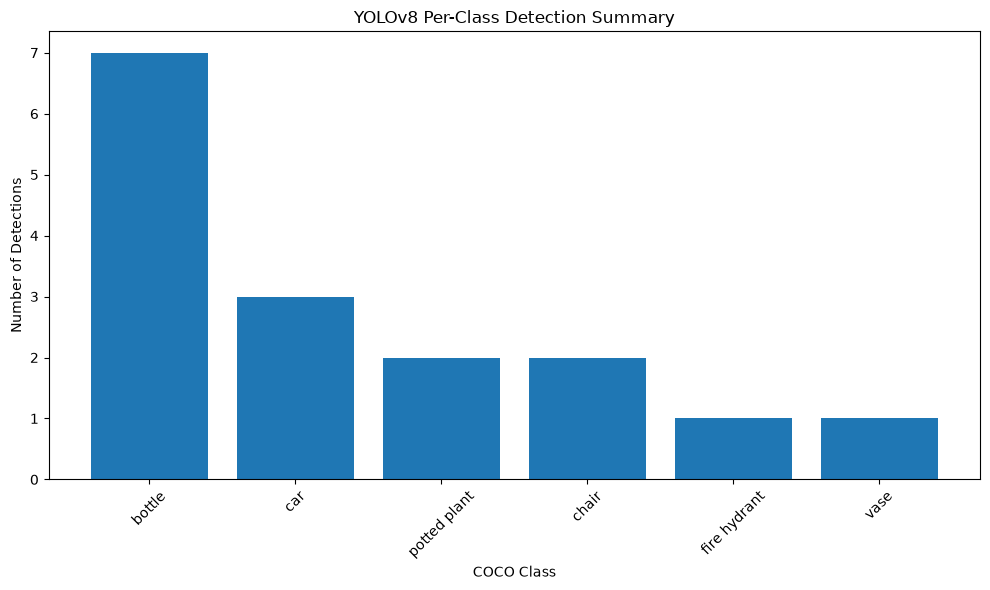

In [62]:
plt.figure(figsize=(10, 6))

plt.bar(
    class_df["Class"],
    class_df["Count"]
)

plt.title("YOLOv8 Per-Class Detection Summary")
plt.xlabel("COCO Class")
plt.ylabel("Number of Detections")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/yolo_class_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.5 Why YOLO Generalises

YOLO is a single-stage object detection architecture.

Instead of running a separate detector for every object class, YOLO processes the image in a single forward pass and predicts bounding boxes, class probabilities, and confidence scores.

After predictions are generated, Non-Maximum Suppression (NMS) removes redundant overlapping detections.

The YOLOv8 Nano model is designed for a good speed-to-accuracy trade-off.

Larger variants such as YOLOv8s, YOLOv8m, YOLOv8l and YOLOv8x generally require more computational resources but can provide improved accuracy.

The pretrained COCO model can detect 80 object classes without requiring separate manually designed rules for each class.

# Task 5 — Integrated Pipeline & Final Comparison

## Objective

Combine YuNet face detection and YOLO object detection in a single real-time webcam pipeline.

YuNet detections are displayed using green boxes and YOLO detections using red boxes.

In [63]:
cap = cv2.VideoCapture(0)

print("Integrated pipeline started.")
print("Press Q to stop.")

while True:
    
    ret, frame = cap.read()
    
    if not ret:
        break
    
    h, w = frame.shape[:2]
    
    # ==================================
    # 1. YuNet Face Detection
    # ==================================
    
    detector.setInputSize((w, h))
    
    _, faces = detector.detect(frame)
    
    if faces is not None:
        
        for face in faces:
            
            x, y, fw, fh = face[:4].astype(int)
            confidence = face[-1]
            
            # GREEN = FACE
            cv2.rectangle(
                frame,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )
            
            landmarks = face[4:14].reshape(5, 2).astype(int)
            
            for point in landmarks:
                
                cv2.circle(
                    frame,
                    tuple(point),
                    3,
                    (255, 0, 0),
                    -1
                )
            
            cv2.putText(
                frame,
                f"Face {confidence:.2f}",
                (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )
    
    # ==================================
    # 2. YOLO Object Detection
    # ==================================
    
    results = model(
        frame,
        verbose=False
    )
    
    boxes = results[0].boxes
    
    if boxes is not None:
        
        for box in boxes:
            
            x1, y1, x2, y2 = (
                box.xyxy[0]
                .cpu()
                .numpy()
                .astype(int)
            )
            
            confidence = float(
                box.conf[0]
            )
            
            class_id = int(
                box.cls[0]
            )
            
            class_name = model.names[class_id]
            
            # RED = YOLO
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 0, 255),
                2
            )
            
            cv2.putText(
                frame,
                f"{class_name} {confidence:.2f}",
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 255),
                2
            )
    
    # ==================================
    # Display
    # ==================================
    
    cv2.imshow(
        "YuNet + YOLO Integrated Pipeline",
        frame
    )
    
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Integrated pipeline started.
Press Q to stop.


## 5.2 Morphological Pre-Cleaning

A light morphological opening operation can be used as a preprocessing step for noise reduction.

The purpose is to demonstrate how classical preprocessing can be integrated before a deep-learning detector.

The original and preprocessed frames can be compared in terms of detection count.

In [65]:
def morphological_preprocess(frame):
    
    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )
    
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )
    
    cleaned = cv2.morphologyEx(
        gray,
        cv2.MORPH_OPEN,
        kernel
    )
    
    return cleaned

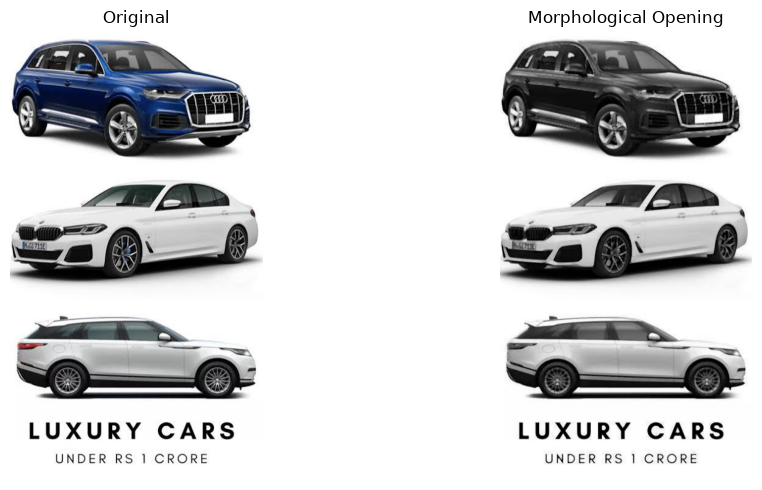

In [66]:
test_frame = cv2.imread(
    "data/images/cars.jpeg"
)

cleaned = morphological_preprocess(
    test_frame
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(
        test_frame,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    cleaned,
    cmap="gray"
)

plt.title("Morphological Opening")
plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
def benchmark_face(num_frames=100):
    
    cap = cv2.VideoCapture(0)
    
    start = time.time()
    
    count = 0
    
    while count < num_frames:
        
        ret, frame = cap.read()
        
        if not ret:
            break
        
        h, w = frame.shape[:2]
        
        detector.setInputSize((w, h))
        
        detector.detect(frame)
        
        count += 1
    
    elapsed = time.time() - start
    
    cap.release()
    
    return count / elapsed

In [68]:
face_fps = benchmark_face(100)

print(
    f"Face Detection FPS: {face_fps:.2f}"
)

Face Detection FPS: 14.55


In [69]:
def benchmark_yolo(num_frames=100):
    
    cap = cv2.VideoCapture(0)
    
    start = time.time()
    
    count = 0
    
    while count < num_frames:
        
        ret, frame = cap.read()
        
        if not ret:
            break
        
        model(
            frame,
            verbose=False
        )
        
        count += 1
    
    elapsed = time.time() - start
    
    cap.release()
    
    return count / elapsed

In [70]:
yolo_fps = benchmark_yolo(100)

print(
    f"YOLO FPS: {yolo_fps:.2f}"
)

YOLO FPS: 4.53


In [71]:
def benchmark_combined(num_frames=100):
    
    cap = cv2.VideoCapture(0)
    
    start = time.time()
    
    count = 0
    
    while count < num_frames:
        
        ret, frame = cap.read()
        
        if not ret:
            break
        
        h, w = frame.shape[:2]
        
        # YuNet
        detector.setInputSize((w, h))
        detector.detect(frame)
        
        # YOLO
        model(
            frame,
            verbose=False
        )
        
        count += 1
    
    elapsed = time.time() - start
    
    cap.release()
    
    return count / elapsed

In [72]:
combined_fps = benchmark_combined(100)

print(
    f"Combined Pipeline FPS: {combined_fps:.2f}"
)

Combined Pipeline FPS: 3.35


In [73]:
fps_data = {
    "Face Detection": face_fps,
    "YOLO": yolo_fps,
    "Combined": combined_fps
}

fps_df = pd.DataFrame(
    list(fps_data.items()),
    columns=["Pipeline", "FPS"]
)

fps_df

,Pipeline,FPS
0,Face Detection,14.554842
1,YOLO,4.534483
2,Combined,3.354946


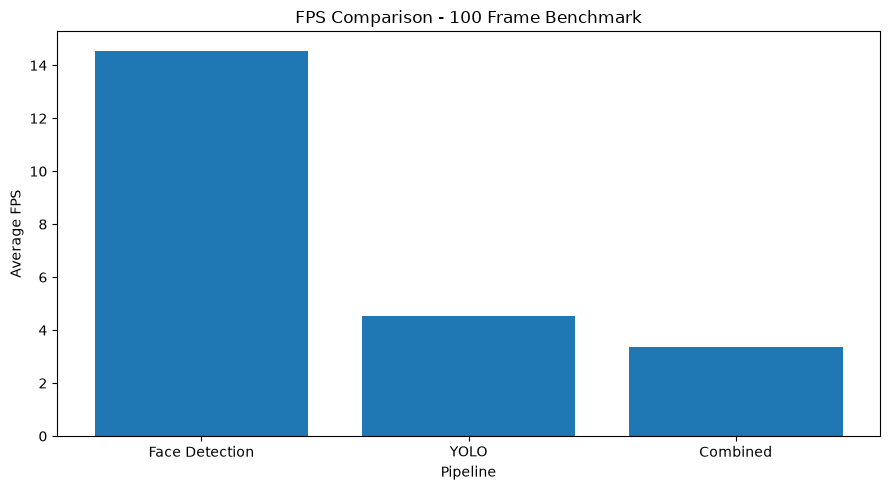

In [74]:
plt.figure(figsize=(9, 5))

plt.bar(
    fps_df["Pipeline"],
    fps_df["FPS"]
)

plt.title(
    "FPS Comparison - 100 Frame Benchmark"
)

plt.xlabel("Pipeline")
plt.ylabel("Average FPS")

plt.tight_layout()

plt.savefig(
    "plots/fps_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

In [75]:
comparison_df = pd.DataFrame({
    
    "Technique": [
        "Morphology",
        "Bitwise Operations",
        "Histograms",
        "YuNet Face Detection",
        "YOLOv8 Object Detection"
    ],
    
    "Type": [
        "Classical",
        "Classical",
        "Classical",
        "Deep Learning",
        "Deep Learning"
    ],
    
    "What It Detects": [
        "Shapes and binary regions",
        "Masked image regions",
        "Pixel intensity distribution",
        "Human faces",
        "Multiple object classes"
    ],
    
    "Lighting Robustness": [
        "Low",
        "Low",
        "Diagnostic",
        "Moderate",
        "Moderate to High"
    ],
    
    "Approx. FPS": [
        "Very High",
        "Very High",
        "Very High",
        round(face_fps, 2),
        round(yolo_fps, 2)
    ],
    
    "Best Use Case": [
        "Noise removal and mask cleaning",
        "ROI and image masking",
        "Brightness/contrast analysis",
        "Real-time face detection",
        "General object detection"
    ]
})

comparison_df

,Technique,Type,What It Detects,Lighting Robustness,Approx. FPS,Best Use Case
0,Morphology,Classical,Shapes and binary regions,Low,Very High,Noise removal and mask cleaning
1,Bitwise Operations,Classical,Masked image regions,Low,Very High,ROI and image masking
2,Histograms,Classical,Pixel intensity distribution,Diagnostic,Very High,Brightness/contrast analysis
3,YuNet Face Detection,Deep Learning,Human faces,Moderate,14.55,Real-time face detection
4,YOLOv8 Object Detection,Deep Learning,Multiple object classes,Moderate to High,4.53,General object detection


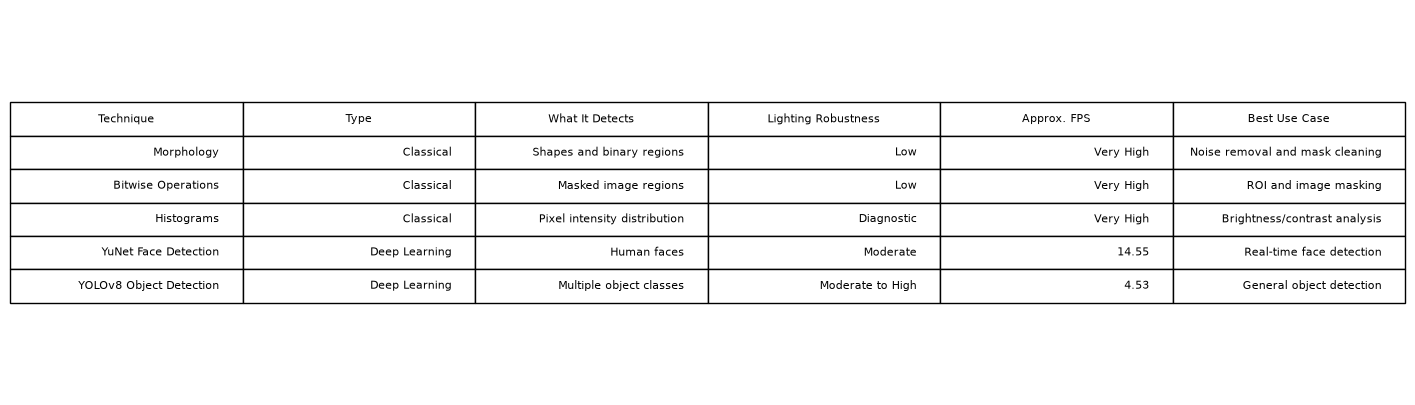

In [76]:
plt.figure(figsize=(18, 5))

plt.axis("off")

table = plt.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)

plt.savefig(
    "plots/results_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5.5 Final Reflection

The project demonstrates a complete computer vision pipeline that combines classical image processing with deep-learning-based detection.

Morphological operations are computationally inexpensive and are useful for removing noise and improving binary masks. Bitwise operations are useful for region-of-interest masking and image composition. Histograms provide information about brightness, contrast, and pixel intensity distribution.

YuNet provides lightweight face detection with bounding boxes, five facial landmarks, and confidence scores. Its score threshold provides a trade-off between detecting difficult faces and reducing false positives.

YOLOv8 provides general-purpose object detection across multiple COCO classes. YOLOv8n provides a strong speed-to-computation trade-off compared with larger YOLO variants.

For a low-power edge device, I would prefer YuNet and YOLOv8n with carefully selected confidence thresholds and lightweight preprocessing. For a cloud-based system with more computational resources, a larger YOLO model such as YOLOv8s or another larger variant could be considered for improved accuracy.

For a real-time monitoring system, the best solution is not necessarily the most accurate model. The final choice should balance accuracy, FPS, memory usage, latency, and hardware limitations.